We will in this notebook code from scratch an MLP (mutli-layer perceptron) for the classification task on MNIST dataset. Everything in the algorithm, from backpropagation to matrix multiplication were be written from scratch. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
A = np.array([[1, 2], [3, 4]])
print(A[1])
liste = [0,1]
a, b = [10,13], [15, 12]
A[liste] = np.c_[a, b]
print(A)

[3 4]
[[10 15]
 [13 12]]


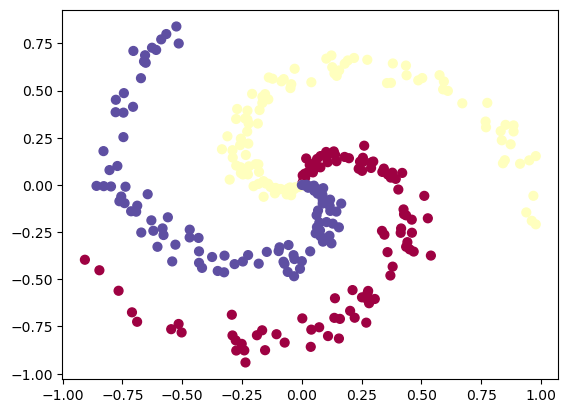

In [9]:
N = 100 #number of points per class
D = 2
K = 3
X = np.zeros((N*K, D)) #data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') #class labels
for j in range(K) : 
    ix = range(N*j, N*(j+1))
    r = np.linspace(0.0, 1, N) #radius
    t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*0.2 #theta
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = j

# let s visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()


Training a softmax linear classifier
Initializing the parameters

We will use the He initialization because it is the one that works the best with the Relu function. The He initialization consists of initializing the weights as follows : 
$$
W N(0, sqrt(2/n_in))
$$

We decided to use He initialization because it is the one that suits the most Relu, the activation function that we will use in the MLP. 

Why Relu needs a special initialization ?
Relu sets half of the inputs on average to zero because : 

So roughly 50% of activations vanish.
If we used a naive initialization, ,the variance of activations would shrink layer after layer, causing :
vanishing signals
slow training
He initialization compensates for this by doubling the variance.


In [14]:
def he_initial(n_in, n_out):
    W = np.random.randn(n_in, n_out) * np.sqrt(2. / n_in)
    b = np.zeros((1, n_out)) #bias is initialized to zero
    return W, b

W,b = he_initial(2,200)
print(W.shape)

(2, 200)
